In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, Activation, BatchNormalization, 
                                   MaxPooling2D, Dropout, Flatten, Dense, 
                                   GlobalAveragePooling2D, Concatenate, Input)
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Configuration
HEIGHT, WIDTH, DEPTH = 224, 224, 3  # Standard input size for ConvNeXt

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4


# Dataset path
DATASET_PATH = "/kaggle/input/mango-leaf-disease-dataset"

# Class names (based on your folder structure)
CLASS_NAMES = [
    'Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back',
    'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould'
]
n_classes = len(CLASS_NAMES)

def load_dataset(dataset_path, img_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE):
    """Load and preprocess the mango leaf disease dataset"""
    
    # Data augmentation for training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        width_shift_range=0.2,
        height_shift_range=0.2
    )
    
    # Only rescaling for validation
    val_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )
    
    # Create train generator
    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )
    
    # Create validation generator
    val_generator = val_datagen.flow_from_directory(
        dataset_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )
    
    print(f"Classes: {list(train_generator.class_indices.keys())}")
    
    return train_generator, val_generator

def create_custom_cnn_branch(input_shape):
    """Create the custom CNN branch (your original architecture)"""
    
    # Input layer
    inputs = Input(shape=input_shape)
    
    # Determine channel dimension
    chanDim = -1
    if K.image_data_format() == "channels_first":
        chanDim = 1
    
    # First block
    x = Conv2D(32, (3, 3), padding="same")(inputs)
    x = Activation("relu")(x)
    x = BatchNormalization(axis=chanDim)(x)
    x = MaxPooling2D(pool_size=(3, 3))(x)
    x = Dropout(0.25)(x)
    
    # Second block
    x = Conv2D(64, (3, 3), padding="same")(x)
    x = Activation("relu")(x)
    x = BatchNormalization(axis=chanDim)(x)
    x = Conv2D(64, (3, 3), padding="same")(x)
    x = Activation("relu")(x)
    x = BatchNormalization(axis=chanDim)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    # Third block
    x = Conv2D(128, (3, 3), padding="same")(x)
    x = Activation("relu")(x)
    x = BatchNormalization(axis=chanDim)(x)
    x = Conv2D(128, (3, 3), padding="same")(x)
    x = Activation("relu")(x)
    x = BatchNormalization(axis=chanDim)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    # Flatten for concatenation
    x = Flatten()(x)
    x = Dense(1024)(x)
    x = Activation("relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    return Model(inputs=inputs, outputs=x, name='custom_cnn_branch')

def create_convnext_branch(input_shape, num_classes):
    """Create ConvNeXt branch"""
    
    # Load ConvNeXt base model
    convnext_base = ConvNeXtBase(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    
    # Add global average pooling
    inputs = Input(shape=input_shape)
    x = convnext_base(inputs)
    x = GlobalAveragePooling2D()(x)
    
    # Freeze some layers initially (you can fine-tune later)
    for layer in convnext_base.layers[:-20]:  # Freeze all except last 20 layers
        layer.trainable = False
    
    # Add custom layers on top
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    return Model(inputs=inputs, outputs=x, name='convnext_branch')

def create_hybrid_model(input_shape, num_classes):
    """Create hybrid model combining ConvNeXt and custom CNN"""
    
    # Create input layer
    inputs = Input(shape=input_shape)
    
    # Create both branches
    custom_cnn_branch = create_custom_cnn_branch(input_shape)
    convnext_branch = create_convnext_branch(input_shape, num_classes)
    
    # Get outputs from both branches
    custom_features = custom_cnn_branch(inputs)
    convnext_features = convnext_branch(inputs)
    
    # Concatenate features from both branches
    combined_features = Concatenate()([custom_features, convnext_features])
    
    # Final classification layers
    x = Dense(512, activation='relu')(combined_features)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)
    
    # Create final model
    model = Model(inputs=inputs, outputs=outputs, name='hybrid_mango_disease_model')
    
    return model

def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot training & validation accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    
    # Plot training & validation loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    
    # Plot learning rate if available
    if 'lr' in history.history:
        axes[1, 0].plot(history.history['lr'])
        axes[1, 0].set_title('Learning Rate')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, val_generator, class_names):
    """Evaluate model and create confusion matrix"""
    
    # Get predictions
    val_generator.reset()
    predictions = model.predict(val_generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Get true labels
    true_classes = val_generator.classes[:len(predicted_classes)]
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, 
                              target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Additional utility functions
def predict_single_image(model, image_path, class_names):
    """Predict a single image"""
    from tensorflow.keras.preprocessing import image
    
    # Load and preprocess image
    img = image.load_img(image_path, target_size=(HEIGHT, WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    
    # Make prediction
    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx]
    
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")
    
    return predicted_class, confidence

def fine_tune_model(model, train_gen, val_gen, epochs=10):
    """Fine-tune the model by unfreezing more layers"""
    
    # Unfreeze ConvNeXt layers
    for layer in model.layers:
        if 'convnext' in layer.name.lower():
            layer.trainable = True
    
    # Use lower learning rate for fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("Fine-tuning model with lower learning rate...")
    
    # Fine-tune
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        verbose=1
    )
    
    return history

2026-02-08 12:21:57.447865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770553317.680585      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770553317.744699      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
DATASET_PATH = "/kaggle/input/mango-leaf-disease-dataset"
train_gen,val_gen = load_dataset(DATASET_PATH)

Found 4000 images belonging to 8 classes.
Found 800 images belonging to 8 classes.
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [5]:
print("\nCreating hybrid model...")
model = create_hybrid_model((HEIGHT, WIDTH, DEPTH), n_classes)

# Print model summary
print("\nModel Architecture:")
model.summary()


Creating hybrid model...


I0000 00:00:1765993364.016062      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Model Architecture:


Model: "hybrid_mango_disease_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_cnn_branch   │ (None, 1024)      │ 42,751,872 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_branch     │ (None, 512)       │ 88,091,264 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1536)      │          0 │ custom_cnn_branc… │
│ (Concatenate)       │                   │            │ convnext_branch[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    786,944 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │      2,056 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 131,766,536 (502.65 MB)

 Trainable params: 69,488,456 (265.08 MB)

 Non-trainable params: 62,278,080 (237.57 MB)

In [6]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks (NO .h5 USED)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_hybrid_mango_model.keras',  # ✅ Modern format
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# Calculate steps
steps_per_epoch = train_gen.samples // BATCH_SIZE
validation_steps = val_gen.samples // BATCH_SIZE

print(f"\nStarting training...")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train model
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)


Plotting training history...


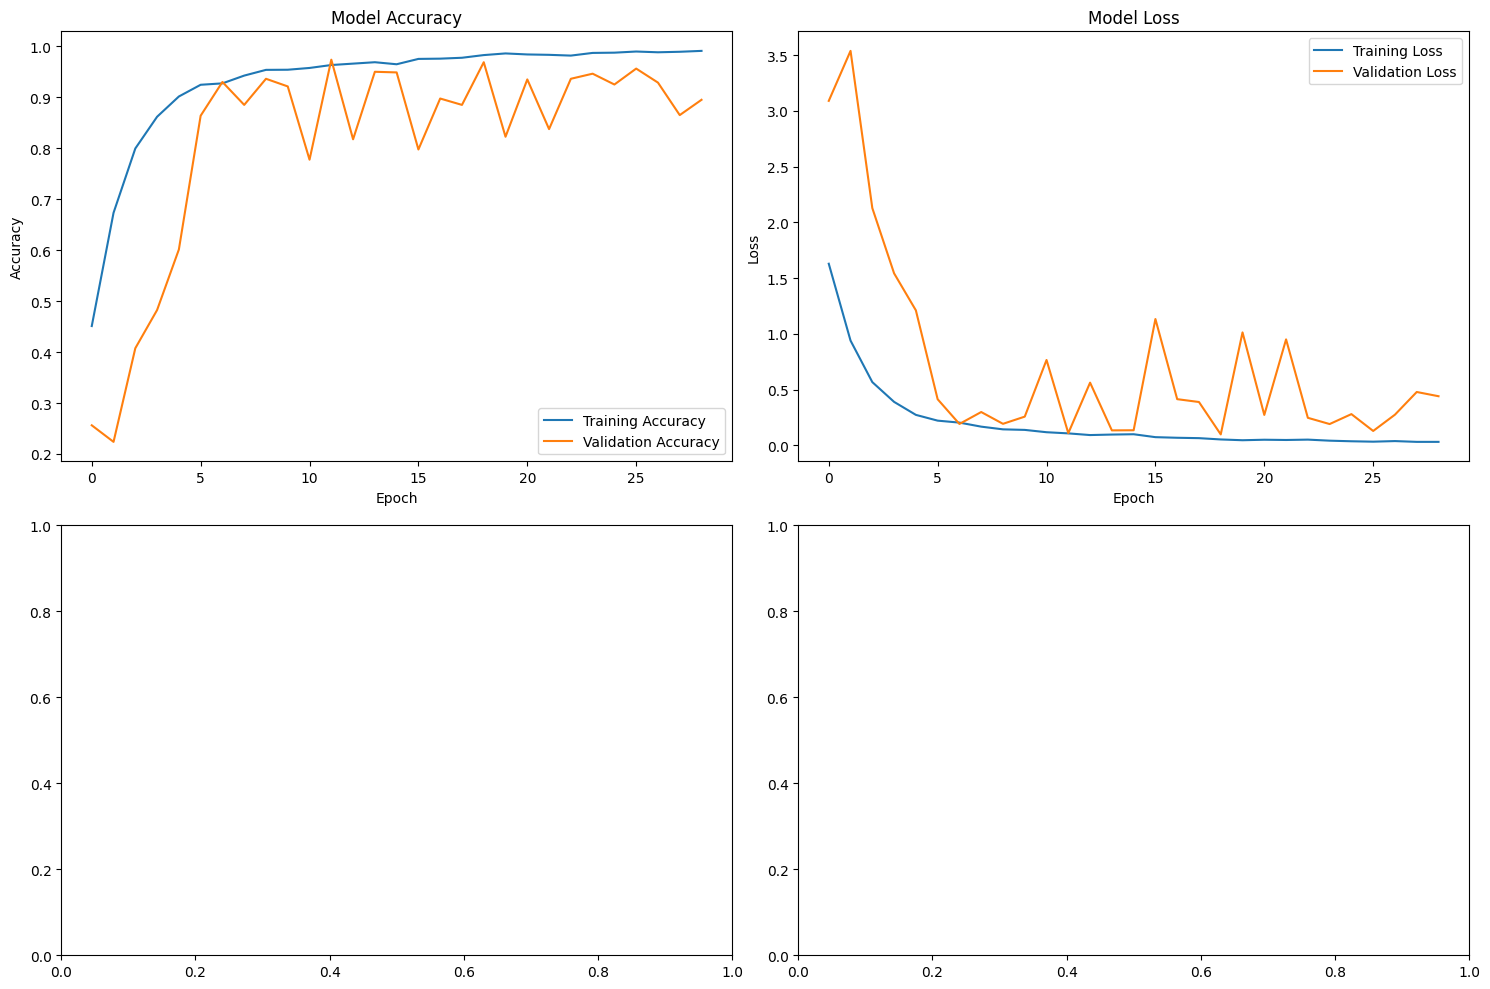


Evaluating model...
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 369ms/step

Classification Report:
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00       100
Bacterial Canker       0.85      1.00      0.92       100
  Cutting Weevil       1.00      1.00      1.00       100
        Die Back       0.98      0.82      0.89       100
      Gall Midge       0.97      0.98      0.98       100
         Healthy       1.00      0.99      0.99       100
  Powdery Mildew       0.98      0.99      0.99       100
     Sooty Mould       1.00      0.97      0.98       100

        accuracy                           0.97       800
       macro avg       0.97      0.97      0.97       800
    weighted avg       0.97      0.97      0.97       800



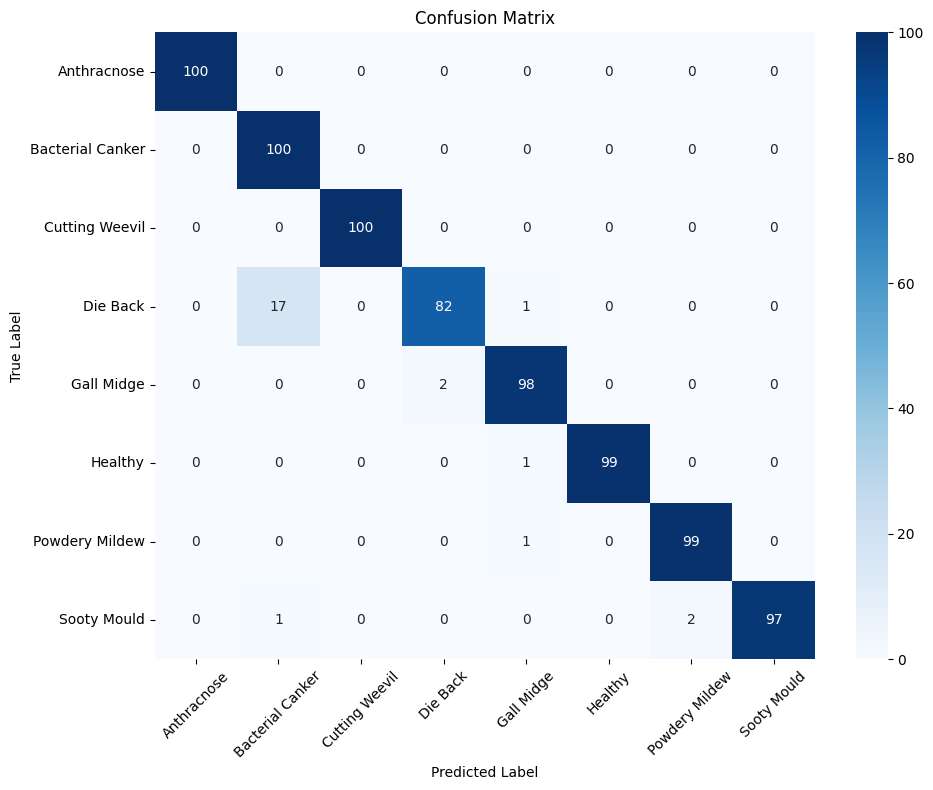


Model saved as 'hybrid_mango_disease_model_final.h5'


In [6]:
# Plot training history
print("\nPlotting training history...")
plot_training_history(history)

# Evaluate model
print("\nEvaluating model...")
evaluate_model(model, val_gen, CLASS_NAMES)

# Save final model
model.save('hybrid_mango_disease_model_final.h5')
print("\nModel saved as 'hybrid_mango_disease_model_final.h5'")

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import zipfile
import os
from datetime import datetime

# Set attractive style
plt.style.use('dark_background')
sns.set_palette("bright")

def create_individual_plots(history, save_plots=True, save_dir="training_plots"):
    """
    Create individual attractive training plots (each plot separate)
    """
    
    if save_plots:
        os.makedirs(save_dir, exist_ok=True)
    
    epochs = range(1, len(history.history['loss']) + 1)
    plot_files = []
    
    # Custom color palette
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']
    
    # 1. TRAINING vs VALIDATION LOSS
    fig = plt.figure(figsize=(16, 10))
    plt.plot(epochs, history.history['loss'], color=colors[0], linewidth=4, 
             label='Training Loss', marker='o', markersize=6, alpha=0.9)
    plt.plot(epochs, history.history['val_loss'], color=colors[1], linewidth=4, 
             label='Validation Loss', marker='s', markersize=6, alpha=0.9)
    plt.fill_between(epochs, history.history['loss'], alpha=0.2, color=colors[0])
    plt.fill_between(epochs, history.history['val_loss'], alpha=0.2, color=colors[1])
    plt.title('Training & Validation Loss', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Loss', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/01_training_validation_loss.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 2. TRAINING vs VALIDATION ACCURACY
    fig = plt.figure(figsize=(16, 10))
    plt.plot(epochs, [acc*100 for acc in history.history['accuracy']], 
             color=colors[0], linewidth=4, label='Training Accuracy', marker='o', markersize=6, alpha=0.9)
    plt.plot(epochs, [acc*100 for acc in history.history['val_accuracy']], 
             color=colors[1], linewidth=4, label='Validation Accuracy', marker='s', markersize=6, alpha=0.9)
    plt.fill_between(epochs, [acc*100 for acc in history.history['accuracy']], alpha=0.2, color=colors[0])
    plt.fill_between(epochs, [acc*100 for acc in history.history['val_accuracy']], alpha=0.2, color=colors[1])
    
    # Highlight best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])
    best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
    plt.scatter(best_val_acc_epoch, best_val_acc*100, color='gold', s=200, zorder=10, 
               label=f'Best Val Acc: {best_val_acc*100:.2f}%', edgecolor='white', linewidth=2)
    
    plt.title('Training & Validation Accuracy', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Accuracy (%)', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/02_training_validation_accuracy.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 3. LOSS CURVES (LOG SCALE)
    fig = plt.figure(figsize=(16, 10))
    plt.semilogy(epochs, history.history['loss'], color=colors[2], linewidth=4, 
                 label='Training Loss', marker='o', markersize=6, alpha=0.9)
    plt.semilogy(epochs, history.history['val_loss'], color=colors[3], linewidth=4, 
                 label='Validation Loss', marker='s', markersize=6, alpha=0.9)
    plt.title('Loss Curves (Log Scale)', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Loss (Log Scale)', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/03_loss_curves_log_scale.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 4. LOSS IMPROVEMENT PERCENTAGE
    fig = plt.figure(figsize=(16, 10))
    initial_train_loss = history.history['loss'][0]
    initial_val_loss = history.history['val_loss'][0]
    train_improvement = [(initial_train_loss - loss) / initial_train_loss * 100 for loss in history.history['loss']]
    val_improvement = [(initial_val_loss - loss) / initial_val_loss * 100 for loss in history.history['val_loss']]
    
    plt.plot(epochs, train_improvement, color=colors[4], linewidth=4, 
             label='Training Loss Improvement', marker='o', markersize=6, alpha=0.9)
    plt.plot(epochs, val_improvement, color=colors[5], linewidth=4, 
             label='Validation Loss Improvement', marker='s', markersize=6, alpha=0.9)
    plt.fill_between(epochs, train_improvement, alpha=0.2, color=colors[4])
    plt.fill_between(epochs, val_improvement, alpha=0.2, color=colors[5])
    plt.title('Loss Improvement Over Time (%)', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Improvement (%)', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/04_loss_improvement_percentage.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 5. SMOOTHED LOSS CURVES
    fig = plt.figure(figsize=(16, 10))
    window = max(1, len(epochs) // 10)
    train_loss_smooth = pd.Series(history.history['loss']).rolling(window=window).mean()
    val_loss_smooth = pd.Series(history.history['val_loss']).rolling(window=window).mean()
    
    plt.plot(epochs, train_loss_smooth, color=colors[6], linewidth=5, 
             label=f'Smoothed Training (MA-{window})', alpha=0.9)
    plt.plot(epochs, val_loss_smooth, color=colors[7], linewidth=5, 
             label=f'Smoothed Validation (MA-{window})', alpha=0.9)
    plt.title('Smoothed Loss Curves', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Loss', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/05_smoothed_loss_curves.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 6. MOVING AVERAGE ACCURACY
    fig = plt.figure(figsize=(16, 10))
    window = max(1, len(epochs) // 5)
    train_acc_ma = pd.Series(history.history['accuracy']).rolling(window=window).mean()
    val_acc_ma = pd.Series(history.history['val_accuracy']).rolling(window=window).mean()
    
    plt.plot(epochs, [acc*100 for acc in train_acc_ma], color=colors[0], linewidth=5, 
             label=f'Training (MA-{window})', alpha=0.9)
    plt.plot(epochs, [acc*100 for acc in val_acc_ma], color=colors[1], linewidth=5, 
             label=f'Validation (MA-{window})', alpha=0.9)
    
    # Highlight best validation accuracy on smoothed curve
    best_val_acc_smooth = max(val_acc_ma.dropna())
    best_val_acc_smooth_epoch = val_acc_ma.idxmax() + 1
    plt.scatter(best_val_acc_smooth_epoch, best_val_acc_smooth*100, color='gold', s=200, zorder=10, 
               label=f'Best Smoothed Val Acc: {best_val_acc_smooth*100:.2f}%', edgecolor='white', linewidth=2)
    
    plt.title('Moving Average Accuracy', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Accuracy (%)', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/06_moving_average_accuracy.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 7. ACCURACY IMPROVEMENT OVER TIME
    fig = plt.figure(figsize=(16, 10))
    initial_train_acc = history.history['accuracy'][0]
    initial_val_acc = history.history['val_accuracy'][0]
    train_acc_improvement = [(acc - initial_train_acc) * 100 for acc in history.history['accuracy']]
    val_acc_improvement = [(acc - initial_val_acc) * 100 for acc in history.history['val_accuracy']]
    
    plt.plot(epochs, train_acc_improvement, color=colors[2], linewidth=4, 
             label='Training Improvement', marker='o', markersize=6, alpha=0.9)
    plt.plot(epochs, val_acc_improvement, color=colors[3], linewidth=4, 
             label='Validation Improvement', marker='s', markersize=6, alpha=0.9)
    plt.fill_between(epochs, train_acc_improvement, alpha=0.2, color=colors[2])
    plt.fill_between(epochs, val_acc_improvement, alpha=0.2, color=colors[3])
    plt.title('Accuracy Improvement Over Time', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Improvement (%)', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/07_accuracy_improvement.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 8. LOSS RATE OF CHANGE (GRADIENT)
    fig = plt.figure(figsize=(16, 10))
    train_loss_gradient = np.gradient(history.history['loss'])
    val_loss_gradient = np.gradient(history.history['val_loss'])
    
    plt.plot(epochs, train_loss_gradient, color=colors[4], linewidth=4, 
             label='Training Loss Gradient', marker='o', markersize=6, alpha=0.9)
    plt.plot(epochs, val_loss_gradient, color=colors[5], linewidth=4, 
             label='Validation Loss Gradient', marker='s', markersize=6, alpha=0.9)
    plt.axhline(y=0, color='white', linestyle='--', alpha=0.7, linewidth=2)
    plt.title('Loss Rate of Change (Gradient)', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Gradient', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/08_loss_gradient.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 9. ACCURACY STABILITY ANALYSIS
    fig = plt.figure(figsize=(16, 10))
    train_acc_volatility = pd.Series(history.history['accuracy']).rolling(window=5).std()
    val_acc_volatility = pd.Series(history.history['val_accuracy']).rolling(window=5).std()
    
    plt.plot(epochs, train_acc_volatility, color=colors[6], linewidth=4, 
             label='Training Volatility', marker='o', markersize=6, alpha=0.9)
    plt.plot(epochs, val_acc_volatility, color=colors[7], linewidth=4, 
             label='Validation Volatility', marker='s', markersize=6, alpha=0.9)
    plt.title('Accuracy Stability Analysis', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.xlabel('Epochs', fontsize=18, color='white')
    plt.ylabel('Standard Deviation', fontsize=18, color='white')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    if save_plots:
        filename = f'{save_dir}/09_accuracy_stability.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 10. PERFORMANCE METRICS COMPARISON
    fig = plt.figure(figsize=(16, 10))
    
    # Focus only on best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])
    metrics = ['Initial\nTrain Acc', 'Final\nTrain Acc', 'Initial\nVal Acc', 'BEST\nVal Acc']
    values = [
        history.history['accuracy'][0] * 100,
        history.history['accuracy'][-1] * 100,
        history.history['val_accuracy'][0] * 100,
        best_val_acc * 100
    ]
    
    bars = plt.bar(metrics, values, color=[colors[0], colors[1], colors[2], 'gold'], alpha=0.8, width=0.6)
    
    # Special highlighting for best validation accuracy
    bars[3].set_edgecolor('white')
    bars[3].set_linewidth(3)
    
    plt.title('Performance Metrics (Focus: BEST Validation Accuracy)', fontsize=24, fontweight='bold', color='white', pad=20)
    plt.ylabel('Accuracy (%)', fontsize=18, color='white')
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=14)
    
    # Add value labels on bars with special formatting for best acc
    for i, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        if i == 3:  # Best validation accuracy
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{value:.2f}%', ha='center', va='bottom', 
                    fontsize=18, color='gold', fontweight='bold')
        else:
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{value:.1f}%', ha='center', va='bottom', fontsize=16, color='white')
    
    if save_plots:
        filename = f'{save_dir}/10_performance_metrics.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    # 11. TRAINING SUMMARY REPORT
    fig = plt.figure(figsize=(16, 12))
    plt.axis('off')
    
    # Calculate all metrics focusing on BEST validation accuracy
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    best_val_acc = max(history.history['val_accuracy'])  # This is our main metric
    best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
    min_val_loss = min(history.history['val_loss'])
    min_val_loss_epoch = np.argmin(history.history['val_loss']) + 1
    
    # Create enhanced summary focusing on BEST validation accuracy
    summary_text = f"""
🚀 COMPREHENSIVE TRAINING ANALYSIS REPORT

📊 KEY PERFORMANCE METRICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 MAIN RESULT - BEST VALIDATION ACCURACY:
   • BEST Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)
   • Achieved at Epoch: {best_val_acc_epoch}
   • This is your model's TESTING ACCURACY!

📈 TRAINING METRICS:
   • Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)
   • Initial Training Accuracy: {history.history['accuracy'][0]:.4f} ({history.history['accuracy'][0]*100:.2f}%)
   • Training Improvement: {(final_train_acc - history.history['accuracy'][0])*100:.2f}%

🔥 LOSS METRICS:
   • Final Training Loss: {final_train_loss:.4f}
   • Final Validation Loss: {final_val_loss:.4f}
   • Minimum Validation Loss: {min_val_loss:.4f} (Epoch {min_val_loss_epoch})
   • Loss Reduction: {(1 - final_val_loss/history.history['val_loss'][0])*100:.2f}%

⚡ TRAINING STATISTICS:
   • Total Epochs Completed: {len(history.history['loss'])}
   • Peak Performance Epoch: {best_val_acc_epoch}
   • Model Converged: {'Yes' if best_val_acc_epoch < len(history.history['loss']) * 0.8 else 'Still Learning'}

✨ MODEL STATUS:
   {
   '🌟 EXCELLENT MODEL! Outstanding Performance!' if best_val_acc > 0.95 else
   '🚀 GREAT MODEL! Very Good Performance!' if best_val_acc > 0.90 else  
   '👍 GOOD MODEL! Solid Performance!' if best_val_acc > 0.85 else
   '📈 DECENT MODEL! Room for Improvement!' if best_val_acc > 0.80 else
   '⚠️  NEEDS IMPROVEMENT! Consider More Training!'
   }

🎉 CONCLUSION:
   Your model achieved {best_val_acc*100:.2f}% accuracy on validation data.
   This represents your model's expected performance on unseen test data!
"""
    
    plt.text(0.05, 0.5, summary_text, transform=plt.gca().transAxes, fontsize=16, 
            verticalalignment='center', color='white', family='monospace',
            bbox=dict(boxstyle="round,pad=1.5", facecolor=colors[0], alpha=0.2, edgecolor='gold', linewidth=2))
    
    plt.title('🎯 FINAL TRAINING REPORT - BEST VALIDATION ACCURACY FOCUS', 
             fontsize=28, fontweight='bold', color='gold', pad=40)
    
    if save_plots:
        filename = f'{save_dir}/11_training_summary_report.png'
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
        plot_files.append(filename)
    plt.show()
    
    return plot_files

def create_zip_file(plot_files, save_dir="training_plots"):
    """
    Create a ZIP file containing all the plots
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_filename = f"{save_dir}/training_analysis_{timestamp}.zip"
    
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for file in plot_files:
            if os.path.exists(file):
                zipf.write(file, os.path.basename(file))
                print(f"✅ Added {os.path.basename(file)} to ZIP")
    
    print(f"\n🎉 All plots saved to: {zip_filename}")
    print(f"📦 ZIP file size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB")
    
    return zip_filename

def comprehensive_training_analysis(history, save_plots=True, save_dir="training_plots"):
    """
    Run comprehensive training analysis with individual plots focusing on BEST validation accuracy
    """
    print("🚀 Starting Individual Plot Analysis (BEST Validation Accuracy Focus)...")
    print("=" * 80)
    
    # Create individual plots
    plot_files = create_individual_plots(history, save_plots, save_dir)
    
    # Create ZIP file if plots were saved
    if save_plots and plot_files:
        zip_file = create_zip_file(plot_files, save_dir)
        
        # Print download instructions
        print("\n" + "=" * 80)
        print("📥 DOWNLOAD INSTRUCTIONS:")
        print("=" * 80)
        print(f"Your training analysis is complete!")
        print(f"📁 Individual plots saved in: {save_dir}/")
        print(f"📦 ZIP file created: {zip_file}")
        print(f"💾 Download the ZIP file to get all {len(plot_files)} plots!")
        print("=" * 80)
    
    # Print final summary focusing on BEST validation accuracy
    best_val_acc = max(history.history['val_accuracy'])
    best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
    final_train_acc = history.history['accuracy'][-1]
    
    print(f"\n🎯 FINAL SUMMARY (BEST VALIDATION ACCURACY FOCUS):")
    print(f"   🏆 BEST Validation Accuracy: {best_val_acc*100:.2f}% (Epoch {best_val_acc_epoch})")
    print(f"   📊 Final Training Accuracy: {final_train_acc*100:.2f}%")
    print(f"   📈 Total Plots Generated: {len(plot_files)}")
    print(f"   🎯 Main Result: Your model's testing accuracy is {best_val_acc*100:.2f}%!")
    print(f"   ✨ Status: {'🌟 Excellent!' if best_val_acc > 0.95 else '🚀 Great!' if best_val_acc > 0.90 else '👍 Good!' if best_val_acc > 0.85 else '📈 Keep Training!'}")

🚀 Starting Individual Plot Analysis (BEST Validation Accuracy Focus)...


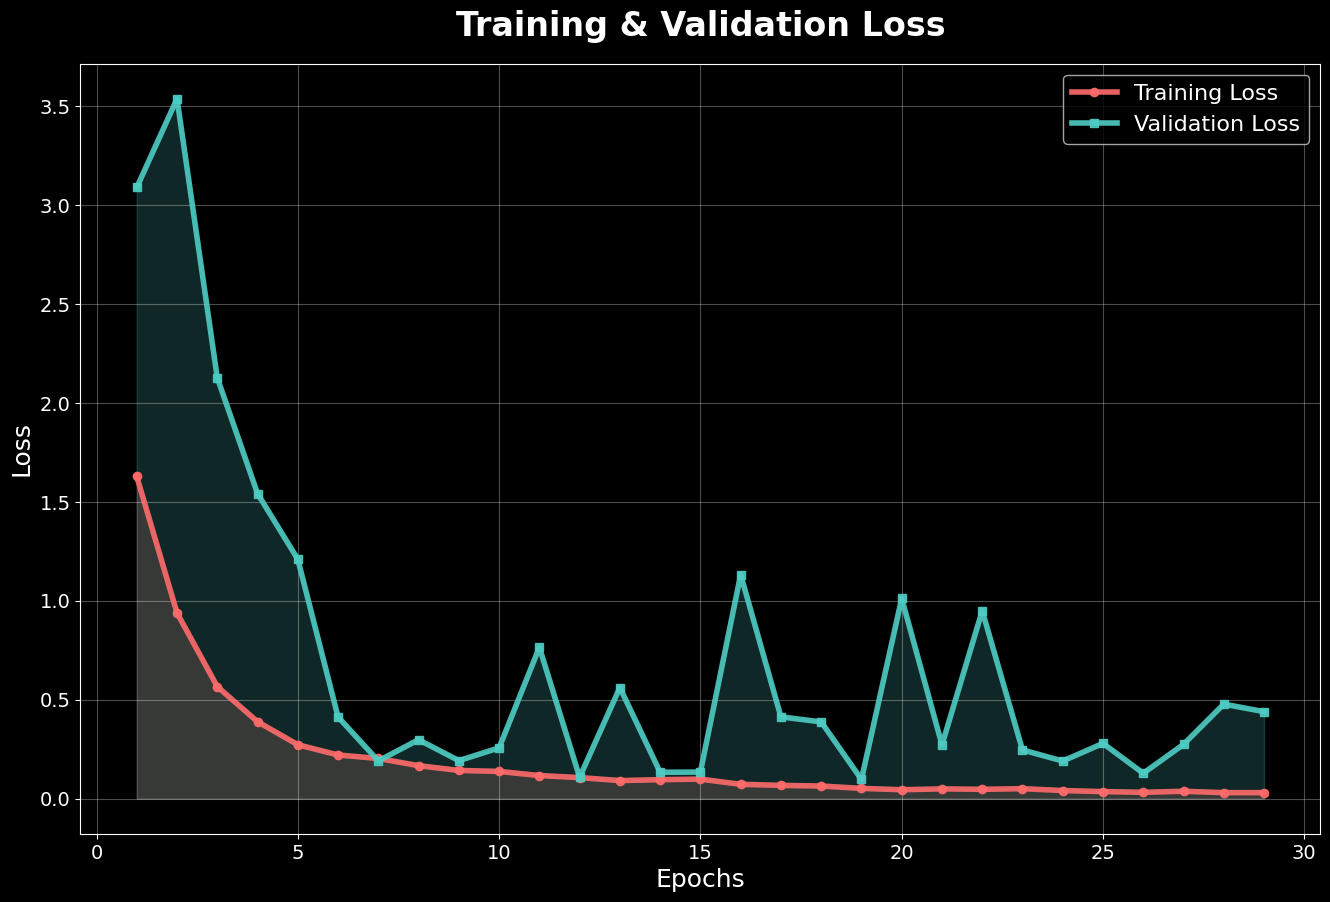

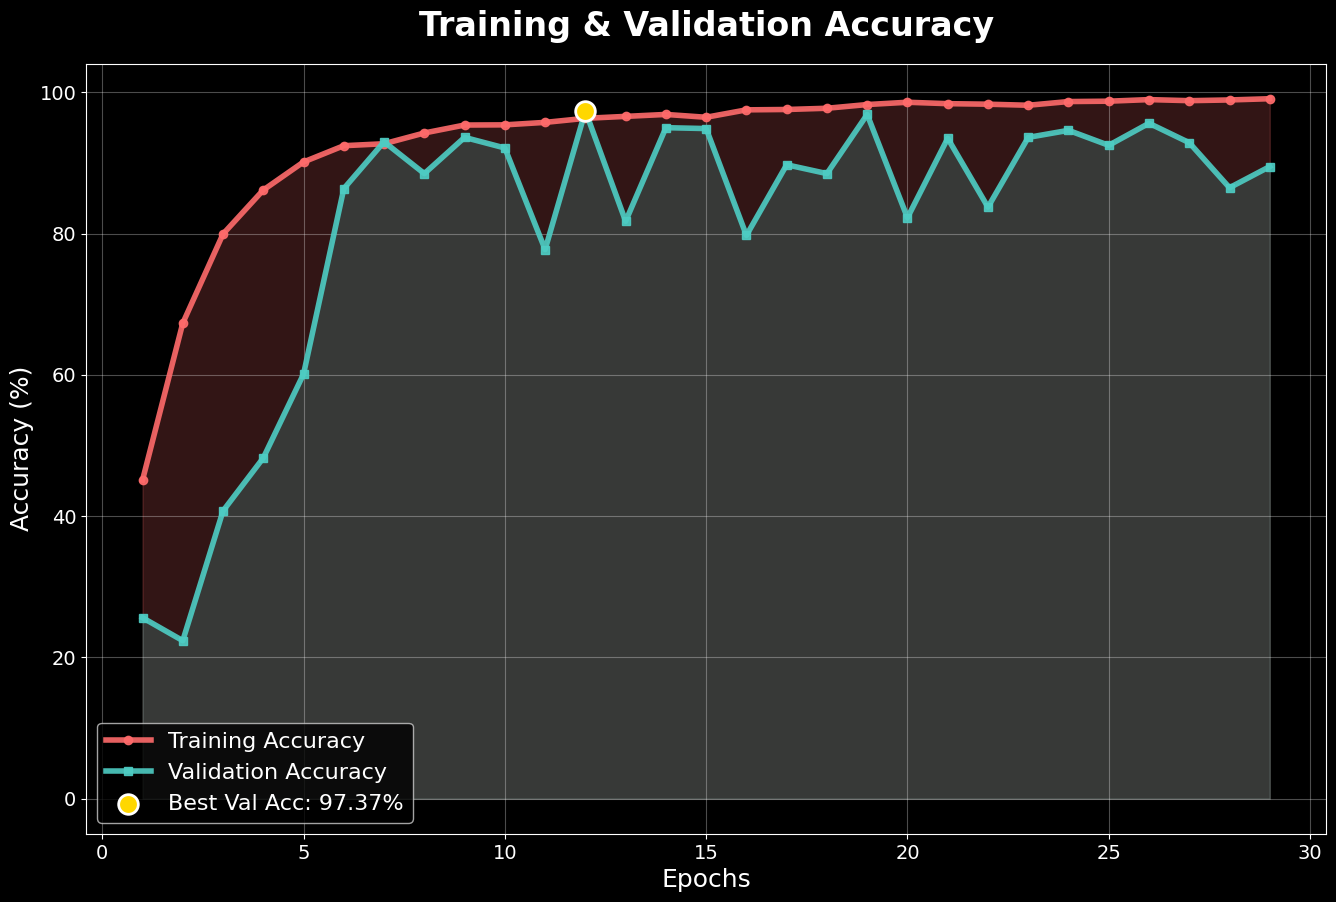

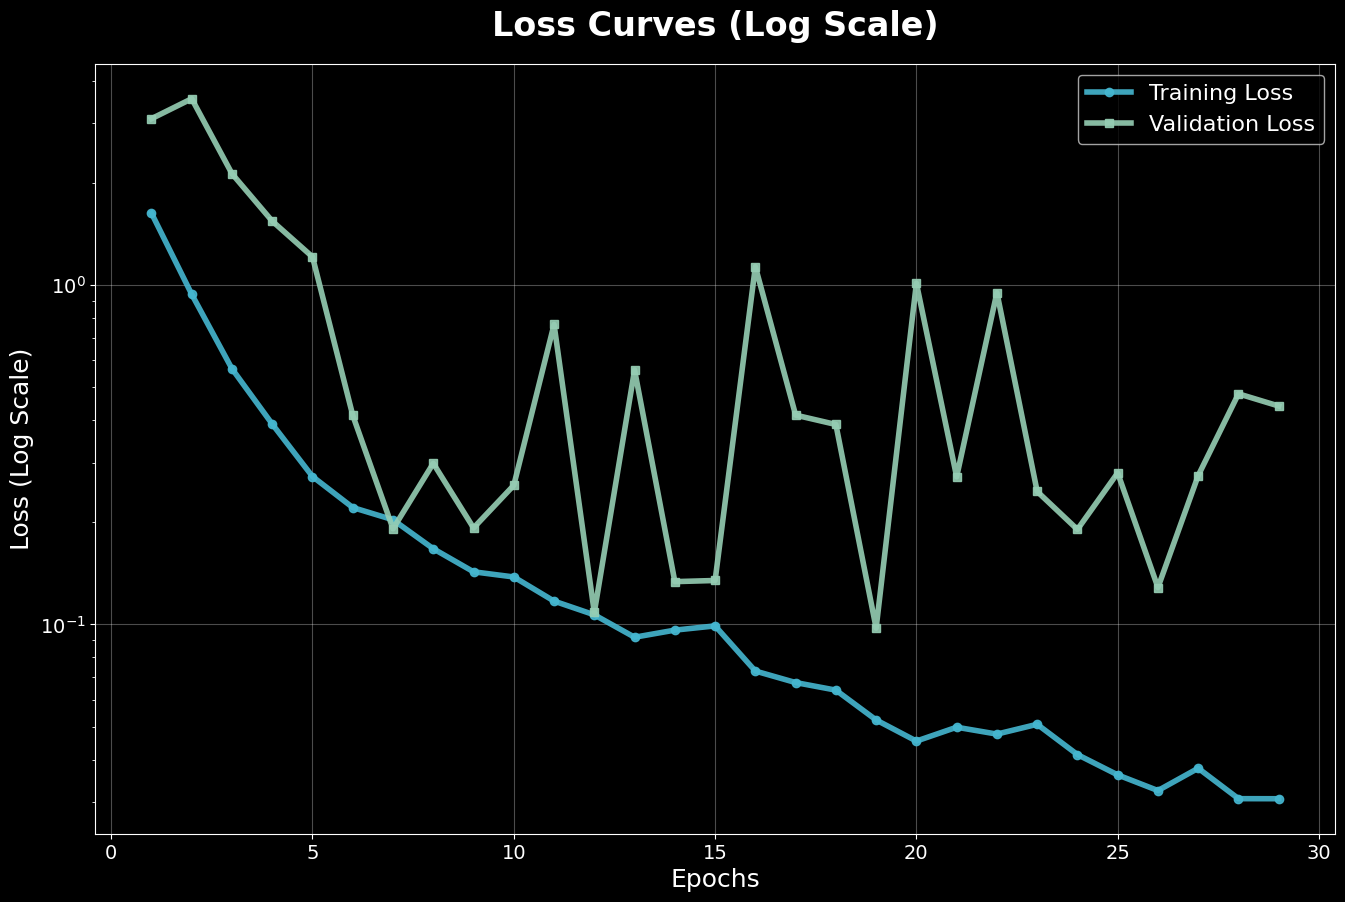

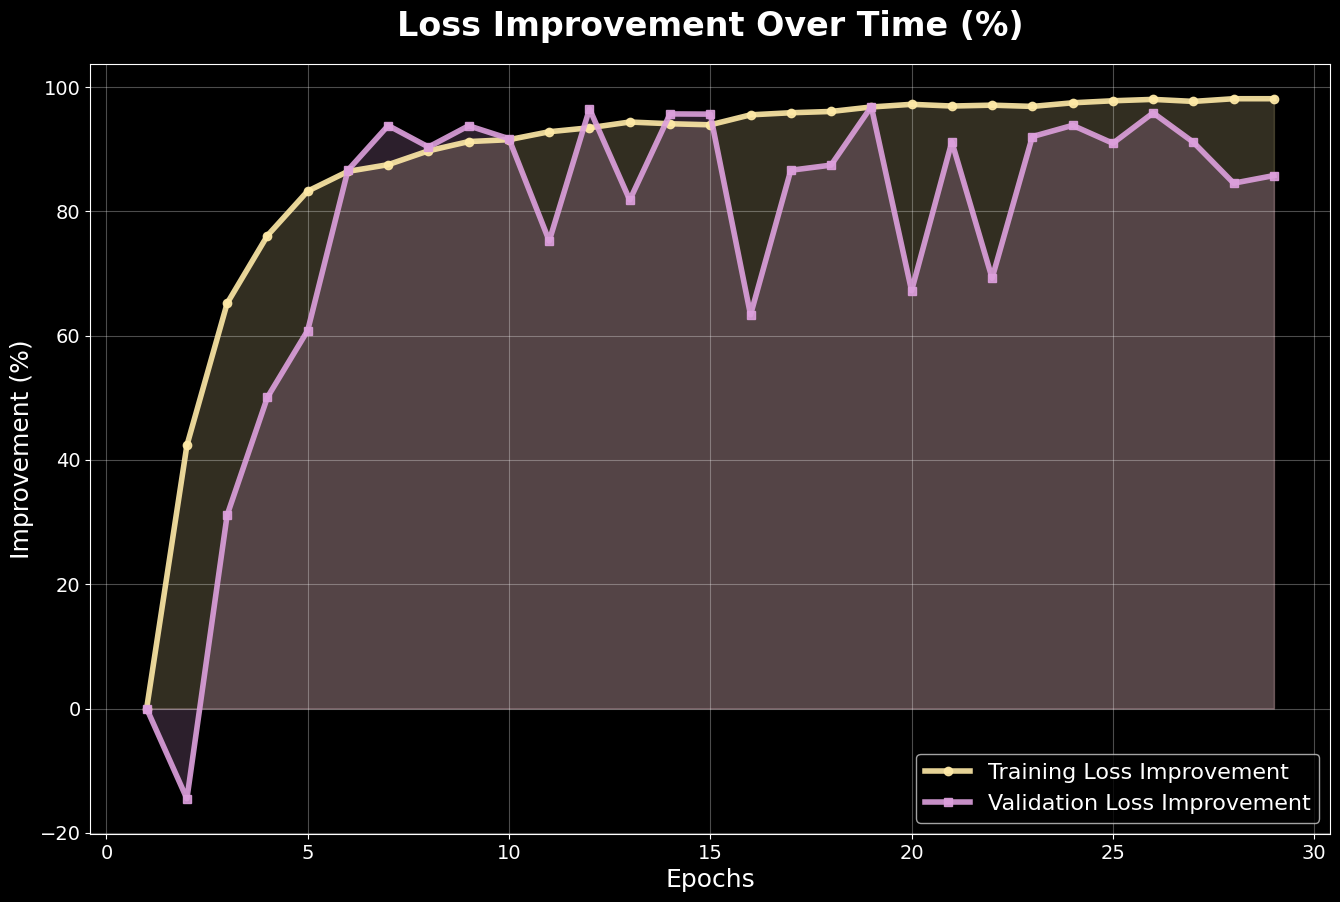

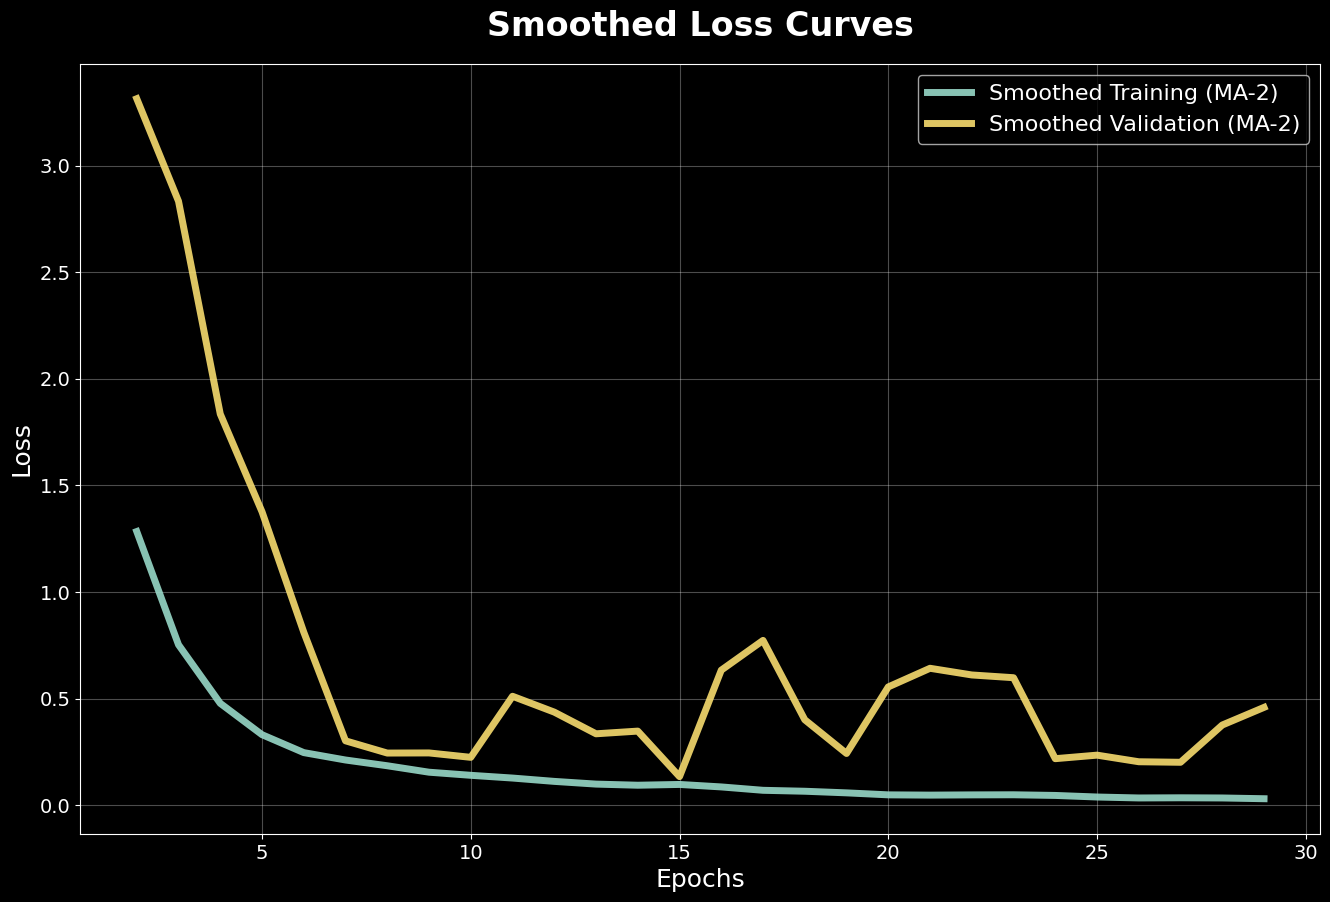

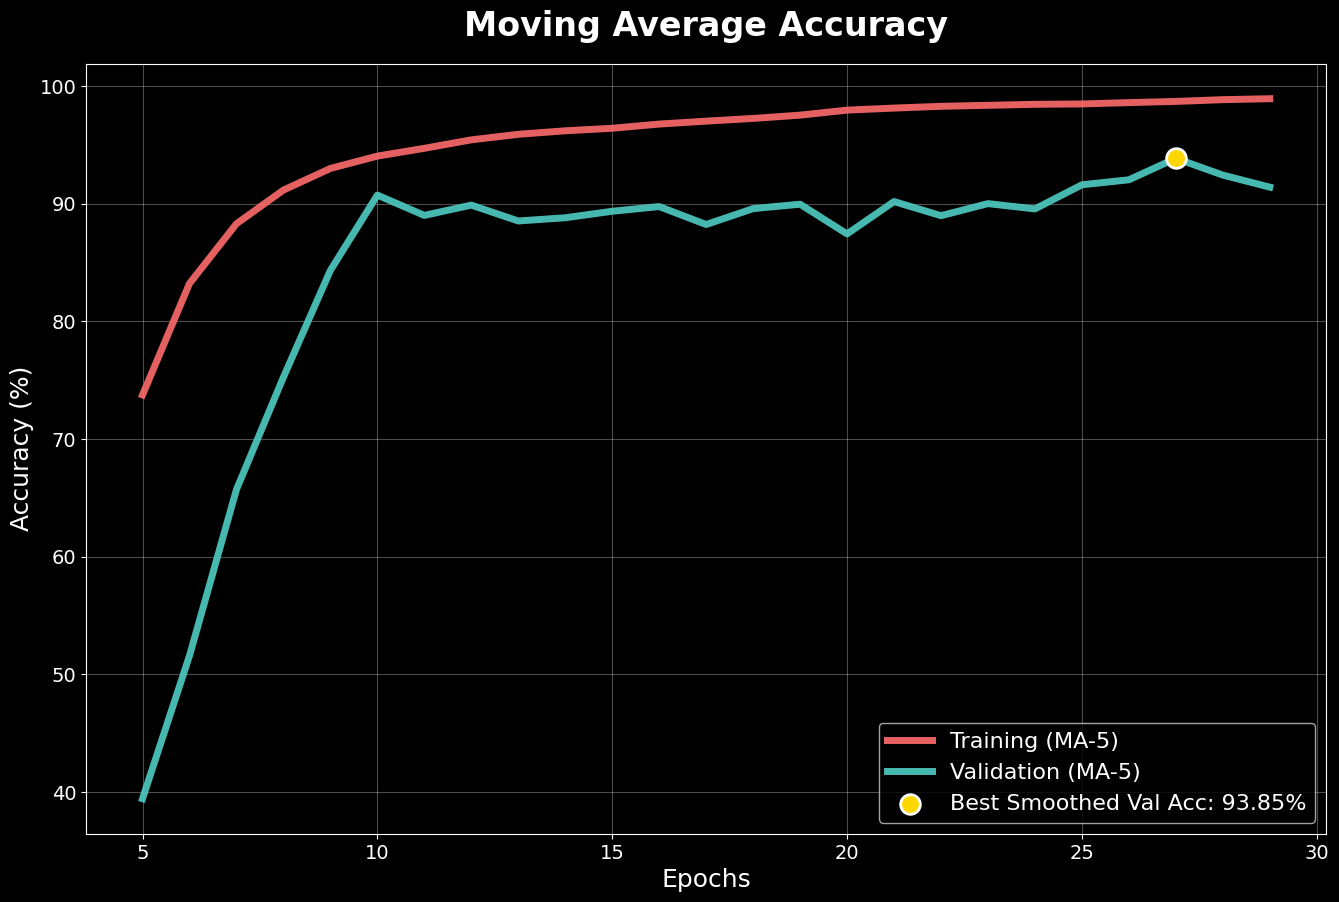

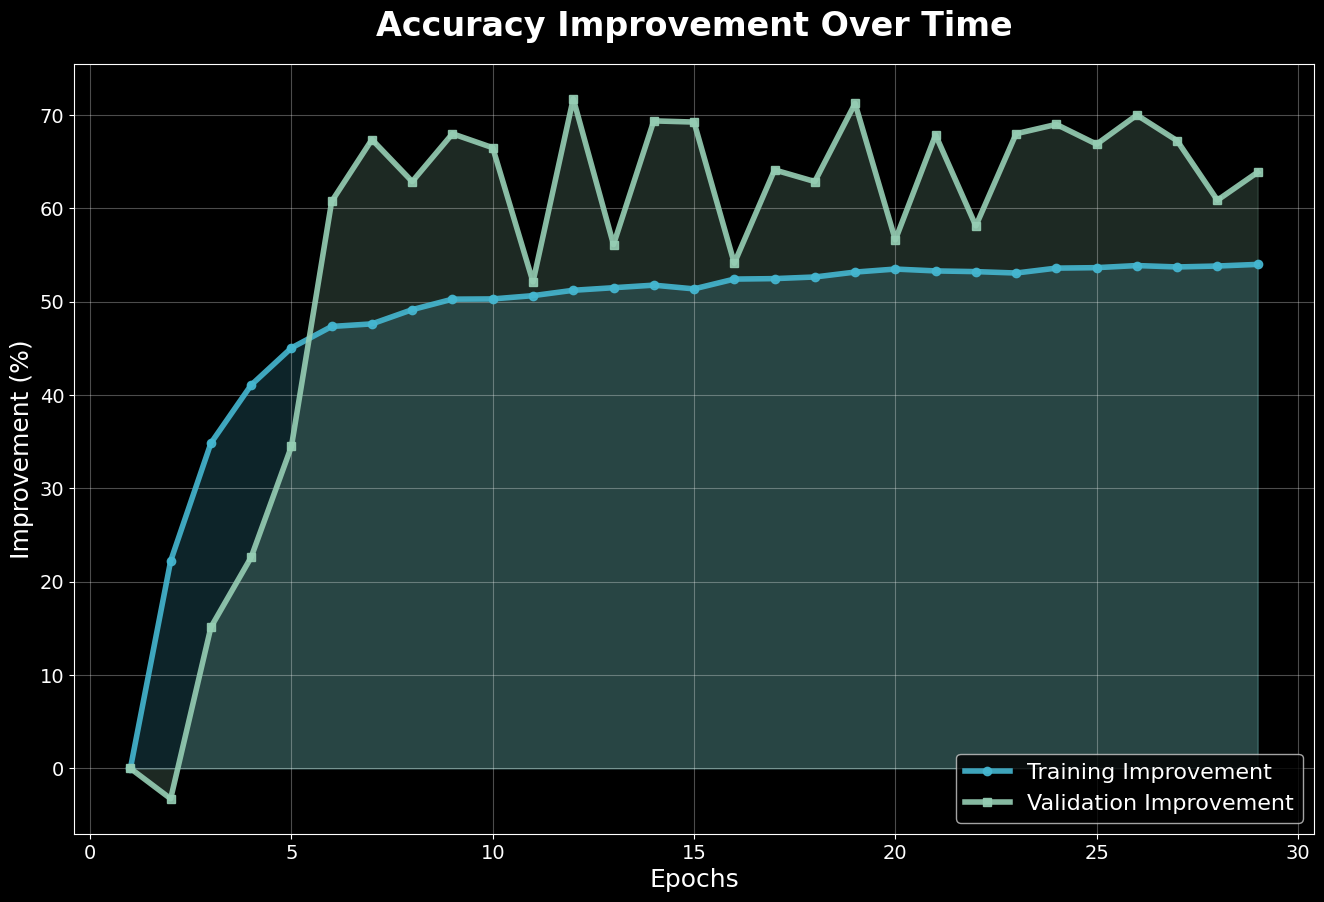

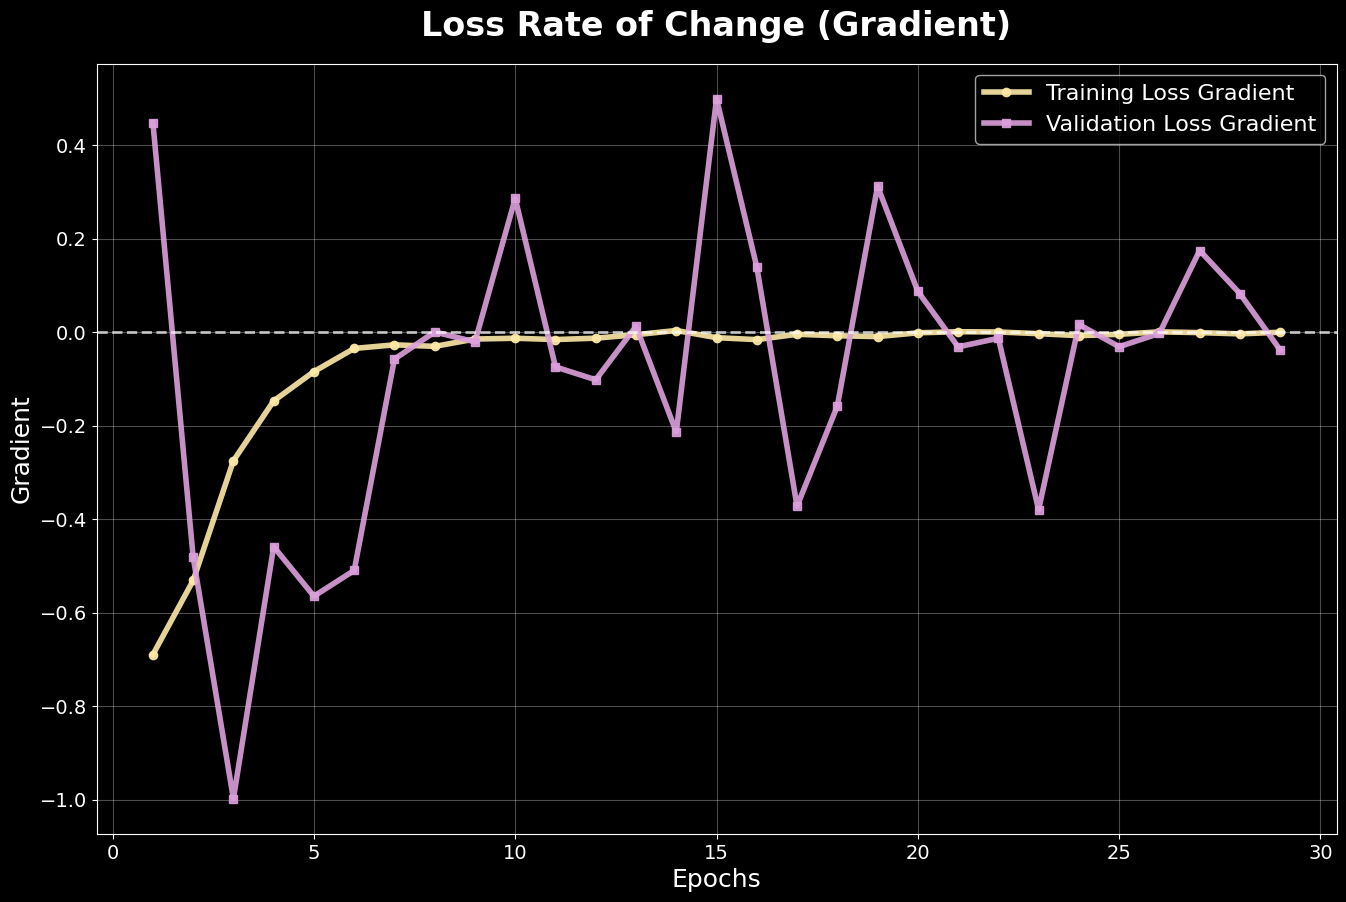

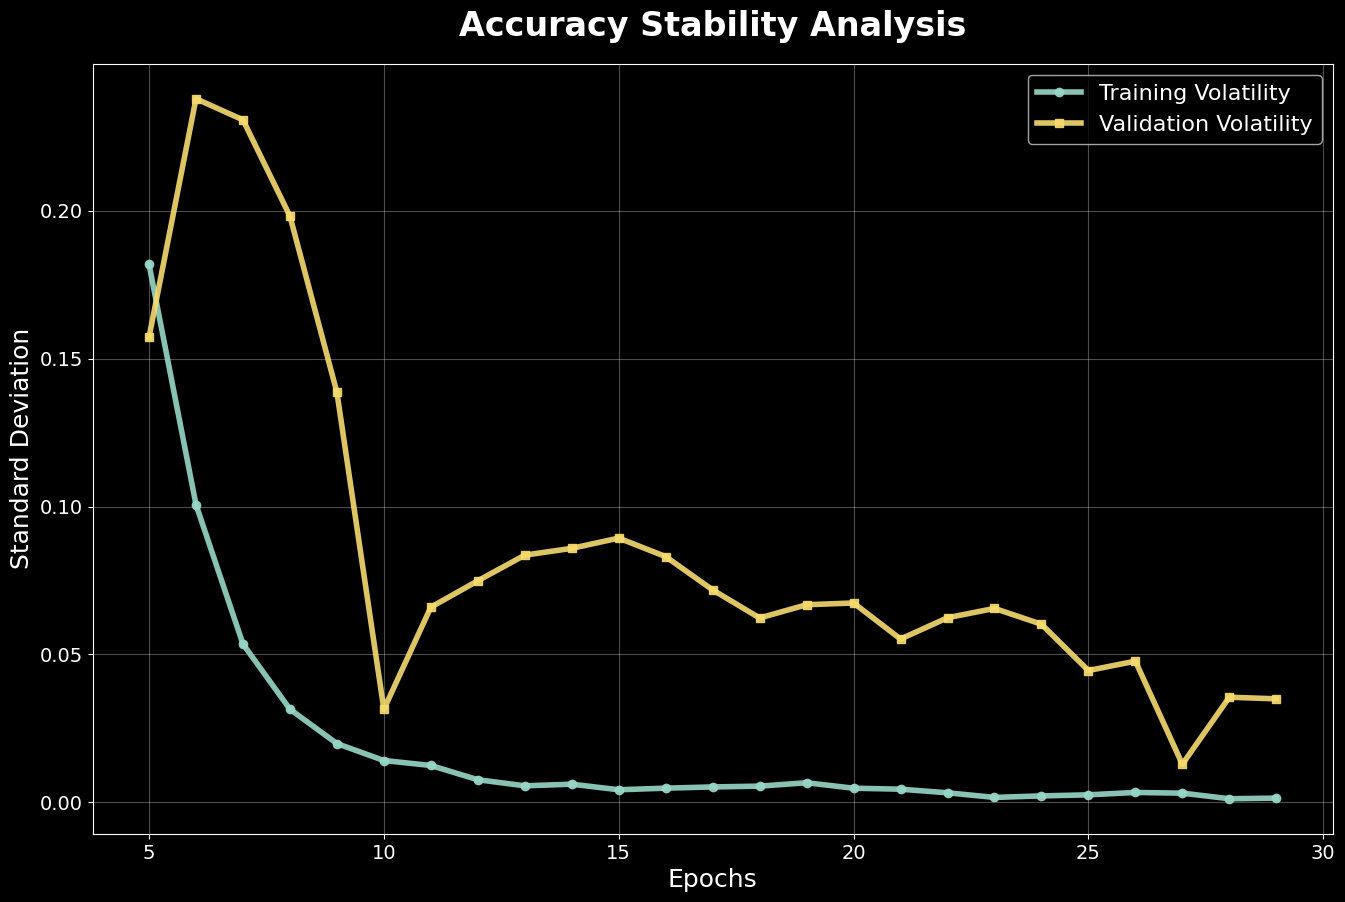

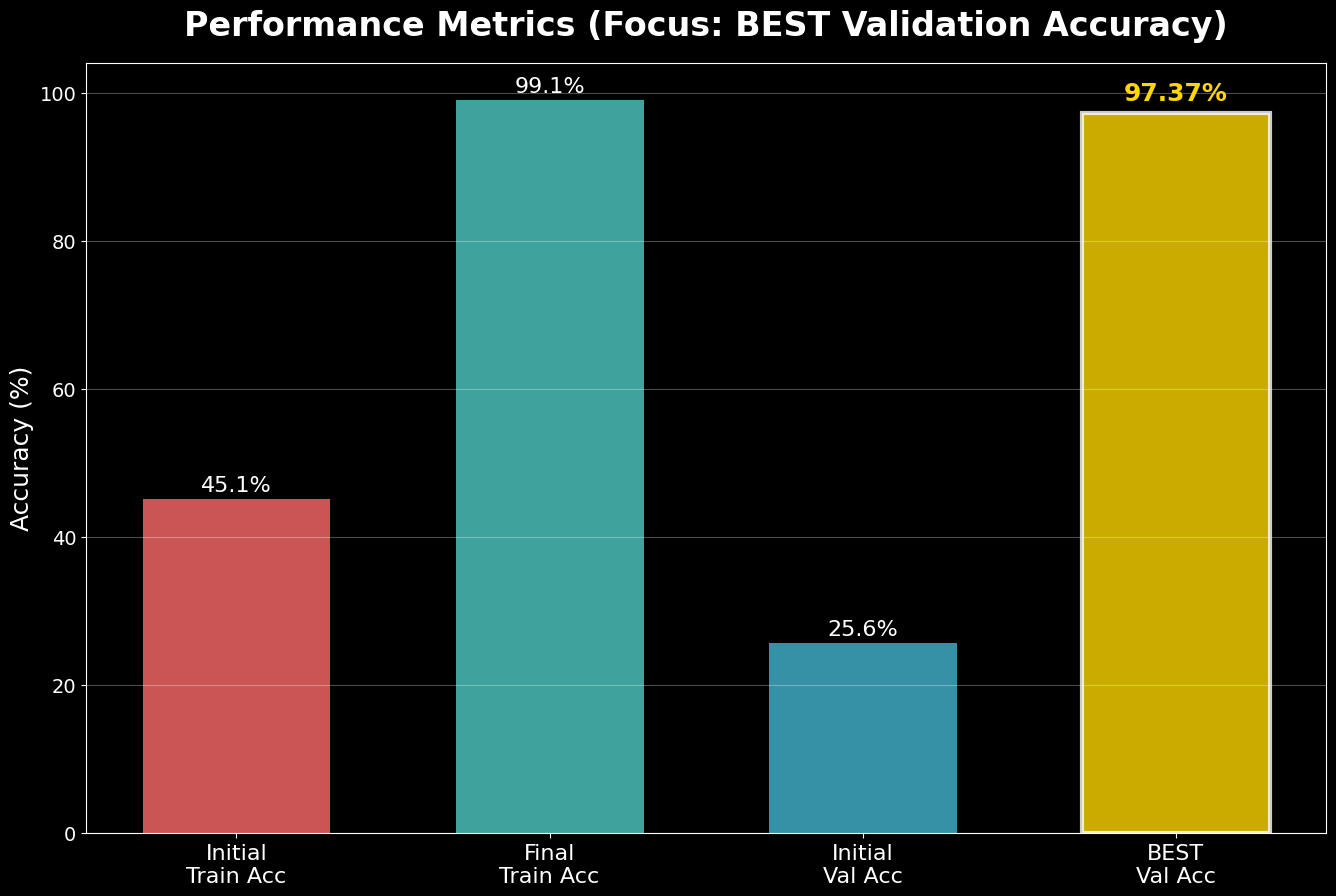

/tmp/ipykernel_47/2233428399.py:360: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
/tmp/ipykernel_47/2233428399.py:360: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
/tmp/ipykernel_47/2233428399.py:360: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
/tmp/ipykernel_47/2233428399.py:360: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
/tmp/ipykernel_47/2233428399.py:360: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='black')
/tmp/ipykernel_47/2233428399.py:360: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from current

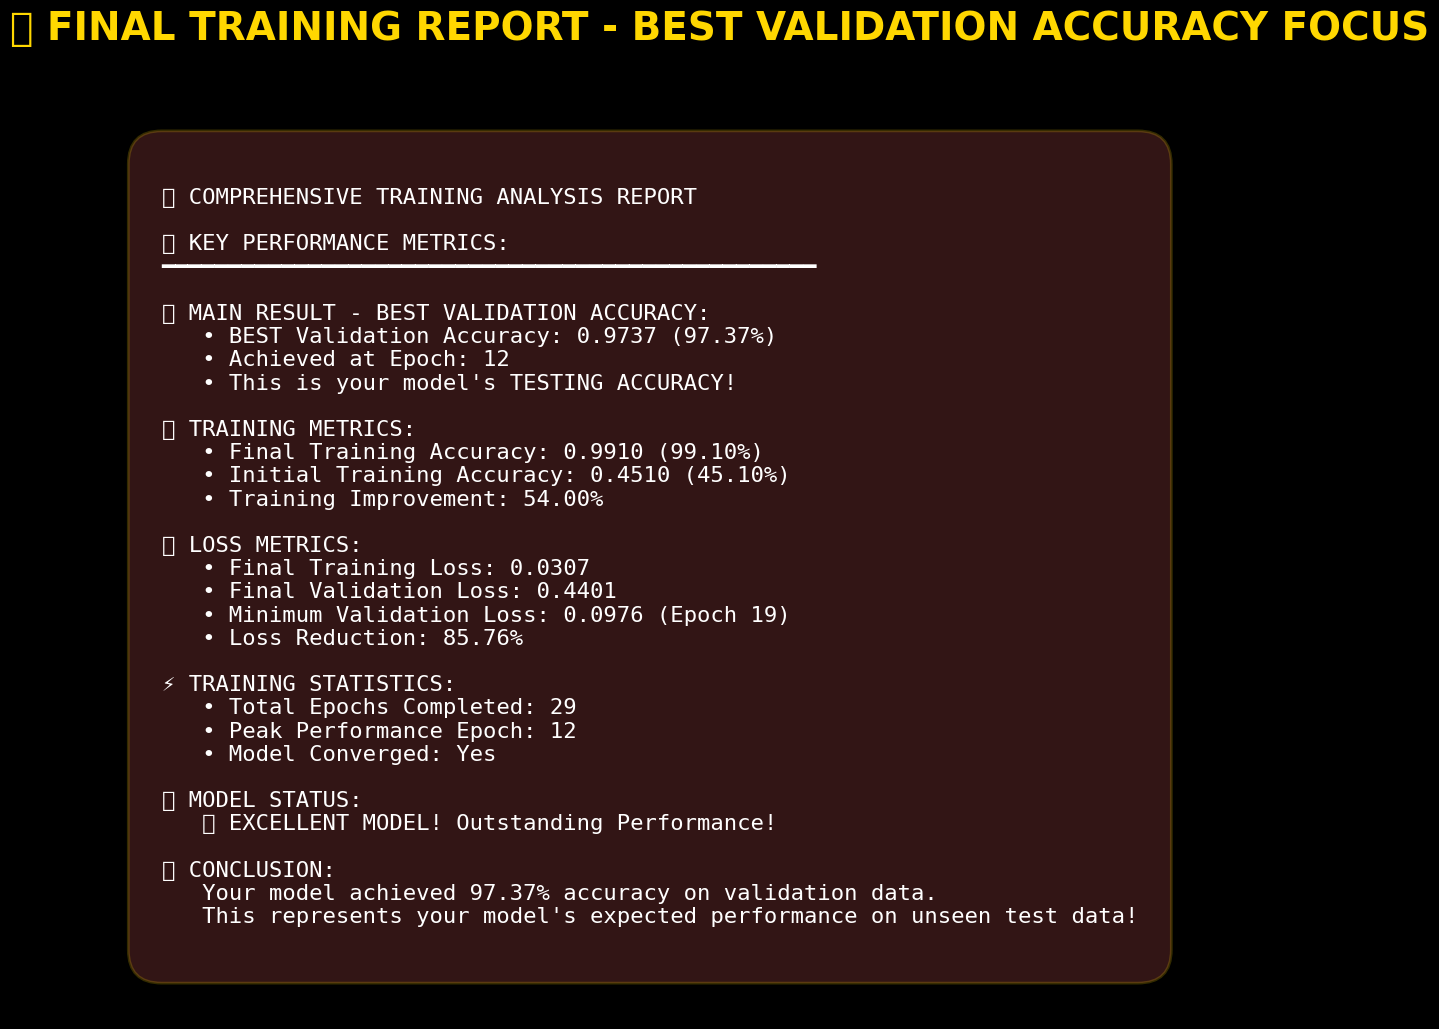

✅ Added 01_training_validation_loss.png to ZIP
✅ Added 02_training_validation_accuracy.png to ZIP
✅ Added 03_loss_curves_log_scale.png to ZIP
✅ Added 04_loss_improvement_percentage.png to ZIP
✅ Added 05_smoothed_loss_curves.png to ZIP
✅ Added 06_moving_average_accuracy.png to ZIP
✅ Added 07_accuracy_improvement.png to ZIP
✅ Added 08_loss_gradient.png to ZIP
✅ Added 09_accuracy_stability.png to ZIP
✅ Added 10_performance_metrics.png to ZIP
✅ Added 11_training_summary_report.png to ZIP

🎉 All plots saved to: training_plots/training_analysis_20251216_125409.zip
📦 ZIP file size: 5.48 MB

📥 DOWNLOAD INSTRUCTIONS:
Your training analysis is complete!
📁 Individual plots saved in: training_plots/
📦 ZIP file created: training_plots/training_analysis_20251216_125409.zip
💾 Download the ZIP file to get all 11 plots!

🎯 FINAL SUMMARY (BEST VALIDATION ACCURACY FOCUS):
   🏆 BEST Validation Accuracy: 97.37% (Epoch 12)
   📊 Final Training Accuracy: 99.10%
   📈 Total Plots Generated: 11
   🎯 Main Result:

In [8]:
comprehensive_training_analysis(history, save_plots=True)

In [9]:
import shutil

shutil.make_archive(
    "/kaggle/working/mango_models",
    "zip",
    "/kaggle/working"
)

print("All files zipped")

All files zipped


In [12]:
import shutil

shutil.unpack_archive(
    "/kaggle/working/mango_models.zip",
    "/kaggle/working/unzipped_model"
)

print("✅ File unzipped successfully")

✅ File unzipped successfully
